<a href="https://colab.research.google.com/github/TOTVScontext/DataScience/blob/main/context.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Leonardo da Silva Pinto | RM: 564929
#Samuel Enzo Domingues Monteiro | RM: 564391
#Guilherme de Araujo Moreira | RM: 561848

In [ ]:
# 1. SETUP, IMPORTAÇÕES E CARGA DOS DADOS
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#baixar as "stopwords"
nltk.download('stopwords', quiet=True)
stop_words_pt = stopwords.words('portuguese')

print("⏳ Carregando as bases de dados...")

# Leitura do CSV (Base com NPS - Usada para o treinamento de Churn)
df_csv = pd.read_csv('reunioes_transcricoes_mockado.csv')

# Leitura do JSON Lines (Base real de produção - Usada para validação de Produto)
df_json = pd.read_json('ANON_transcricao.json', lines=True)

print(f"✅ CSV carregado: {df_csv.shape[0]} reuniões.")
print(f"✅ JSON carregado: {df_json.shape[0]} reuniões reais.")

⏳ Carregando as bases de dados...
✅ CSV carregado: 500 reuniões.
✅ JSON carregado: 1174 reuniões reais.


In [ ]:
# 2. SEGMENTAÇÃO E LIMPEZA DOS DADOS
gravacoes = []

# 2.1 Quebra das transcrições do CSV em trechos/falas
for idx, row in df_csv.iterrows():
    texto = str(row['ANON_TRANSCRICAO'])
    nps = row['NOTA_NPS']

    linhas = texto.split('\n')
    for linha in linhas:
        if ':' in linha:
            locutor, fala = linha.split(':', 1)
            gravacoes.append({
                'ID_MEETING': row['ID_MEETING'],
                'LOCUTOR': locutor.strip(),
                'FALA_BRUTA': fala.strip(),
                'NOTA_NPS': nps
            })

df_trechos = pd.DataFrame(gravacoes)

# 2.2 Criação da Variável Alvo (Risco de Churn)
df_trechos['TARGET_RISCO'] = df_trechos['NOTA_NPS'].apply(lambda x: 1 if x <= 6 else 0) # NPS <= 6 é Risco (1), NPS >= 7 é Seguro/Neutro (0)

# 2.3 Função de Limpeza de Texto (NLP)
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^\w\s]', '', texto) # Remove pontuação
    palavras = texto.split()
    # Remove stopwords mas mantém eventuais marcações como [PESSOA]
    palavras = [w for w in palavras if w not in stop_words_pt]
    return ' '.join(palavras)

df_trechos['FALA_LIMPA'] = df_trechos['FALA_BRUTA'].apply(limpar_texto)

print(f"✅ Segmentação concluída. {df_csv.shape[0]} reuniões geraram {df_trechos.shape[0]} trechos de fala para análise.")

✅ Segmentação concluída. 500 reuniões geraram 3750 trechos de fala para análise.


In [ ]:
# 3. AGREGAÇÃO POR REUNIÃO E VETORIZAÇÃO TF-IDF
print(f"📉 Shape ANTES da agregação (fragmentado por trechos): {df_trechos.shape}")

# Agrupando as falas limpas para "nivel" de reuniao
df_reuniao = df_trechos.groupby('ID_MEETING').agg({
    'FALA_LIMPA': lambda x: ' '.join(x),  # Concatena todas as falas da mesma reunião
    'TARGET_RISCO': 'first'               # O alvo já é o mesmo para toda a reunião
}).reset_index()

print(f"🔄 Agregação concluída. Dataset reestruturado para {df_reuniao.shape[0]} reuniões únicas.")

# Vetorização no texto agregado
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df_reuniao['FALA_LIMPA'])
y = df_reuniao['TARGET_RISCO']

#Separando dados de Treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"📐 Matriz TF-IDF gerada. Treinando com {X_train.shape[0]} reuniões e testando com {X_test.shape[0]} reuniões.")

📉 Shape ANTES da agregação (fragmentado por trechos): (3750, 6)
🔄 Agregação concluída. Dataset reestruturado para 500 reuniões únicas.
📐 Matriz TF-IDF gerada. Treinando com 350 reuniões e testando com 150 reuniões.


In [ ]:
# 4. TREINAMENTO DOS ALGORITMOS

# 4.1 Logistic Regression (Utilizamos class_weight='balanced' para penalizar o modelo caso haja desbalanceamento de classes)
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 4.2 Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

y_pred_baseline = np.ones_like(y_test)

print("✅ Modelos treinados com sucesso. Prontos para avaliação de métricas.")

✅ Modelos treinados com sucesso. Prontos para avaliação de métricas.


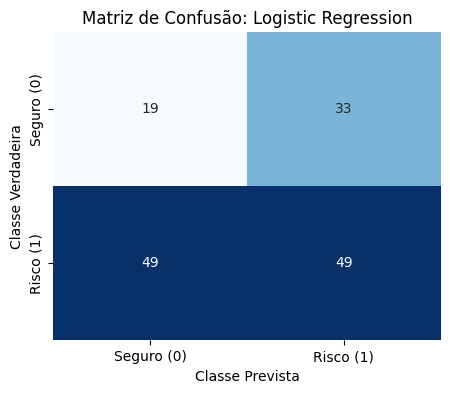


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

  Seguro (0)       0.28      0.37      0.32        52
   Risco (1)       0.60      0.50      0.54        98

    accuracy                           0.45       150
   macro avg       0.44      0.43      0.43       150
weighted avg       0.49      0.45      0.47       150



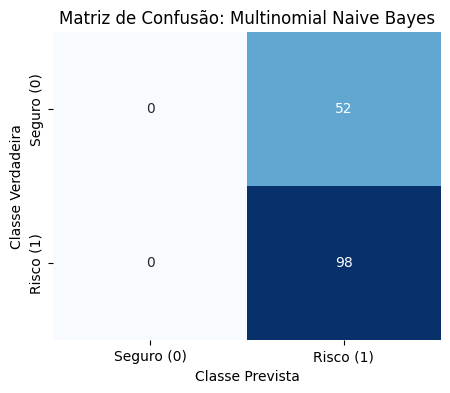


--- Classification Report: Multinomial Naive Bayes ---
              precision    recall  f1-score   support

  Seguro (0)       0.00      0.00      0.00        52
   Risco (1)       0.65      1.00      0.79        98

    accuracy                           0.65       150
   macro avg       0.33      0.50      0.40       150
weighted avg       0.43      0.65      0.52       150


🏆 Resumo Comparativo Focado na Classe de Risco (1):


,Métrica,Baseline Trivial (Chuta Risco),Multinomial Naive Bayes,Logistic Regression
0,Accuracy,0.653,0.653,0.453
1,Precision (Risco),0.653,0.653,0.598
2,Recall (Risco),1.000,1.000,0.500
3,F1-Score (Risco),0.790,0.790,0.544


In [ ]:
# 5. AVALIAÇÃO COMPARATIVA E GRÁFICOS

import warnings
warnings.filterwarnings('ignore')

def plot_eval(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Seguro (0)', 'Risco (1)'],
                yticklabels=['Seguro (0)', 'Risco (1)'])
    ax.set_title(f'Matriz de Confusão: {title}')
    ax.set_ylabel('Classe Verdadeira')
    ax.set_xlabel('Classe Prevista')
    plt.show()

    print(f"\n--- Classification Report: {title} ---")
    print(classification_report(y_true, y_pred, target_names=['Seguro (0)', 'Risco (1)']))

# Visualizacao
plot_eval(y_test, y_pred_lr, 'Logistic Regression')
plot_eval(y_test, y_pred_nb, 'Multinomial Naive Bayes')

# Tabela de Comparação basiuca e simples
dados_comparacao = {
    'Métrica': ['Accuracy', 'Precision (Risco)', 'Recall (Risco)', 'F1-Score (Risco)'],
    'Baseline Trivial (Chuta Risco)': [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_baseline, pos_label=1),
        f1_score(y_test, y_pred_baseline, pos_label=1)
    ],
    'Multinomial Naive Bayes': [
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_nb, pos_label=1),
        f1_score(y_test, y_pred_nb, pos_label=1)
    ],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_lr, pos_label=1)
    ]
}
df_comparacao = pd.DataFrame(dados_comparacao).round(3)
print("\n🏆 Resumo Comparativo Focado na Classe de Risco (1):")
display(df_comparacao)

In [ ]:
 #7. APLICAÇÃO EM DADOS REAIS (JSON TRANSCRIÇÕES)
import warnings
warnings.filterwarnings('ignore')

json_records = []

# Mesma lógica de segmentação para os dados reais
for idx, row in df_json.iterrows():
    texto = str(row['ANON_TRANSCRICAO'])
    for linha in texto.split('\n'):
        if ':' in linha:
            locutor, fala = linha.split(':', 1)
            json_records.append({'ID_MEETING': row['ID_MEETING'], 'FALA': fala.strip()})

df_json_trechos = pd.DataFrame(json_records)

# Classificação por Regras (Keywords dos Produtos TOTVS)
def classificar_produto(texto):
    produtos = []
    if re.search(r'\brm\b', texto, re.IGNORECASE): produtos.append('RM')
    if re.search(r'\bfluig\b', texto, re.IGNORECASE): produtos.append('Fluig')
    if re.search(r'\bprotheus\b', texto, re.IGNORECASE): produtos.append('Protheus')
    if re.search(r'\bdatasul\b', texto, re.IGNORECASE): produtos.append('DataSul')
    if re.search(r'\btotvs\b', texto, re.IGNORECASE): produtos.append('TOTVS')

    return ', '.join(produtos) if produtos else 'Nenhum'

# Aplicação da classificação na base de produção
df_json_trechos['PRODUTOS_DETECTADOS'] = df_json_trechos['FALA'].apply(classificar_produto)

# Filtrando apenas os trechos onde houve menção para exibição
trechos_com_produto = df_json_trechos[df_json_trechos['PRODUTOS_DETECTADOS'] != 'Nenhum']

print(f"🔍 Na base real, mapeamos {trechos_com_produto.shape[0]} falas onde softwares do ecossistema foram mencionados diretamente.")
print("\n📋 Amostra de auditoria em ambiente de produção:")
display(trechos_com_produto.head(120))

🔍 Na base real, mapeamos 2179 falas onde softwares do ecossistema foram mencionados diretamente.

📋 Amostra de auditoria em ambiente de produção:


,ID_MEETING,FALA,PRODUTOS_DETECTADOS
53,1247082,"já fui da RM também. Esquenta não, pode trocar.",RM
110,1247082,supervisores. Eu sou o gerente da área e o [PE...,RM
112,1247082,"foi o primeiro que a gente pensou? RM, por cau...",RM
142,1247082,"Bom, boa tarde. Quem chegou depois? Eu sou [PE...",RM
179,1247082,antes de eu trabalhar no comercial da [EMPRESA...,RM
...,...,...,...
20899,1112702,"[LOCUTOR 17]: uma beleza, porque o que vai aco...",Fluig
20900,1112702,"Atualmente ele tá rodando só em rede interna, ...",Fluig
20904,1112702,"porra, se é só pra isso, hoje eu tenho condiçõ...",Fluig
20914,1112702,"O nosso produto, como ele é instalado dentro d...",Fluig
